In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix, roc_auc_score)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
# Data Overview
df.head(20)


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


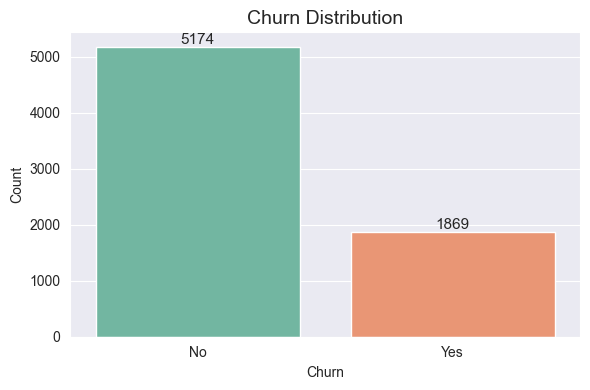

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../images/churn_distribution.png', dpi=150)
plt.show()

# Percentage
print(df['Churn'].value_counts(normalize=True) * 100)

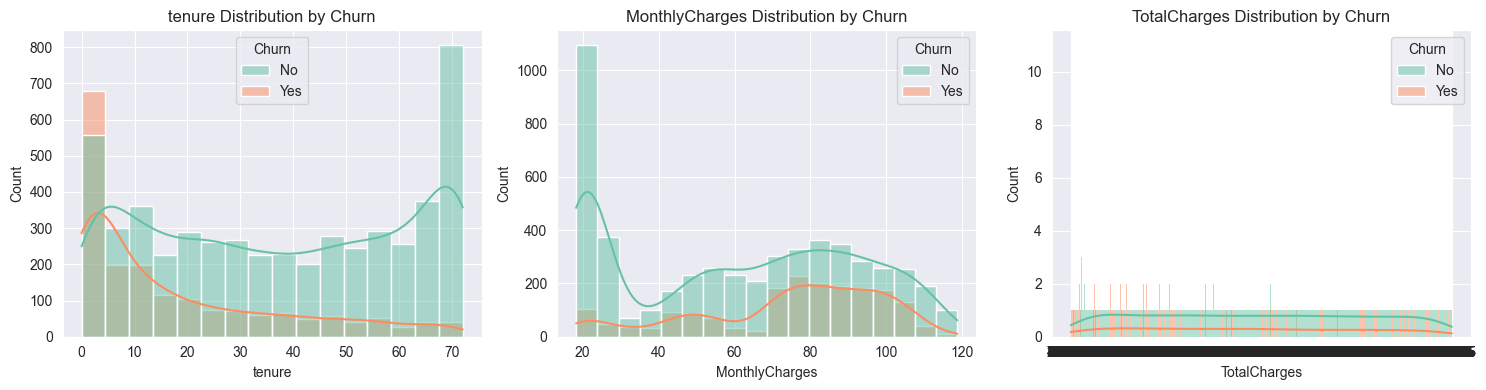

In [6]:
# Numerical Features EDA
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Churn')

plt.tight_layout()
plt.savefig('../images/numerical_distributions.png', dpi=150)
plt.show()

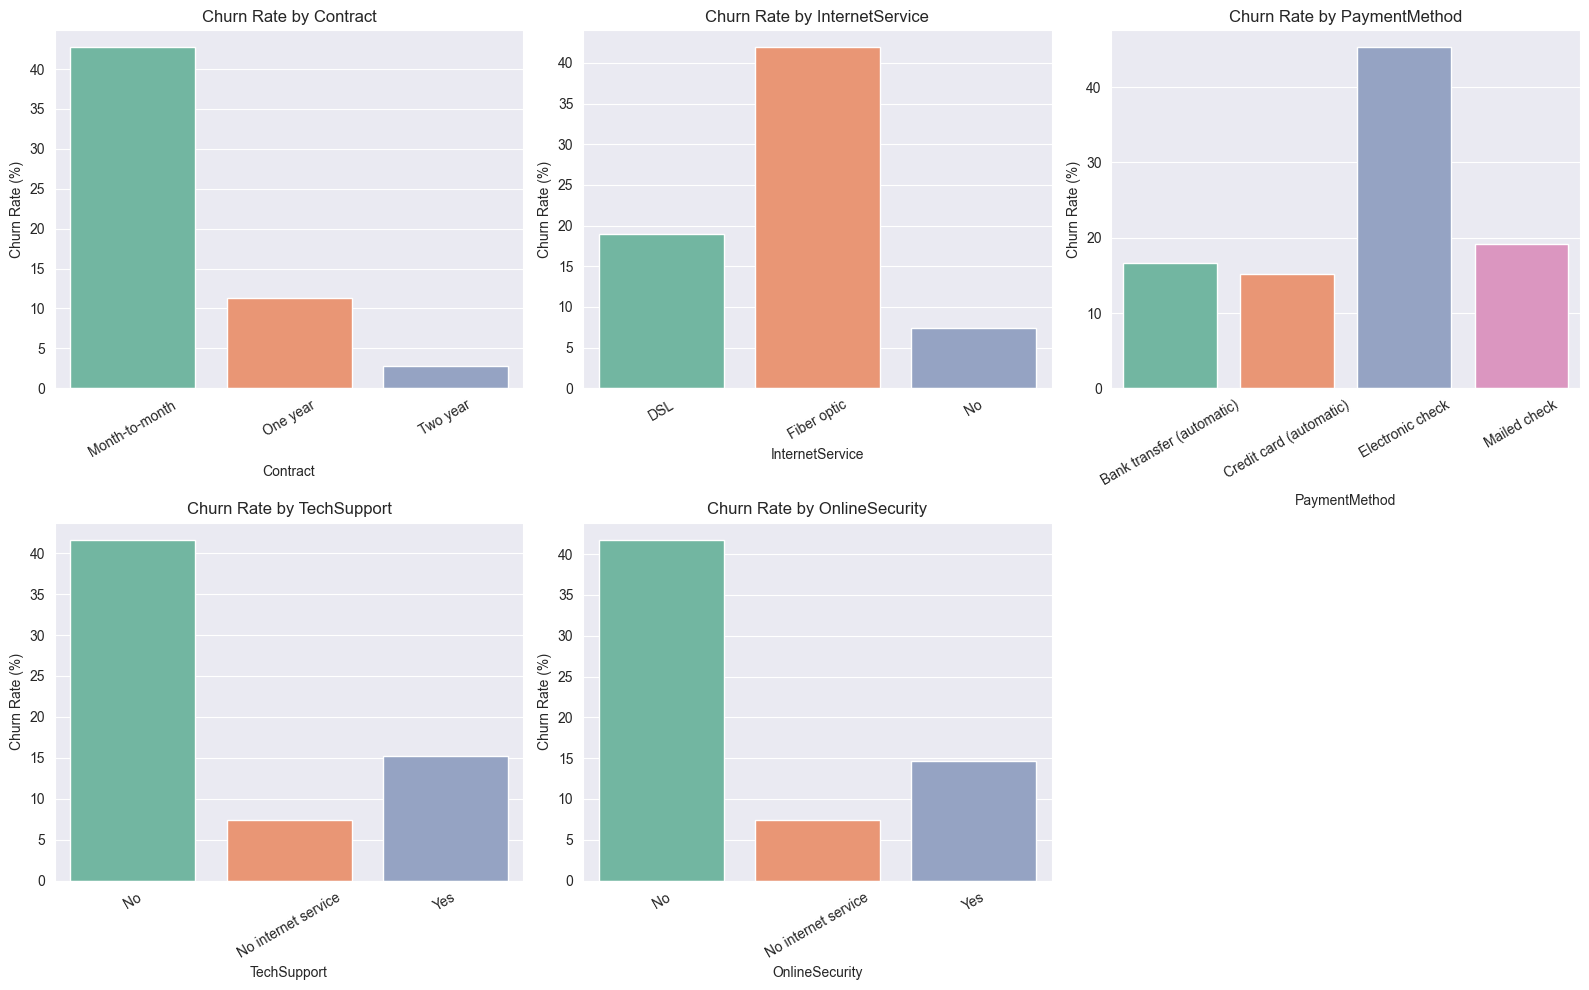

In [7]:
# Categorical Features EDA
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'ChurnRate']

    sns.barplot(data=churn_rate, x=col, y='ChurnRate',
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

# Hide the unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('../images/categorical_churn_rates.png', dpi=150)
plt.show()

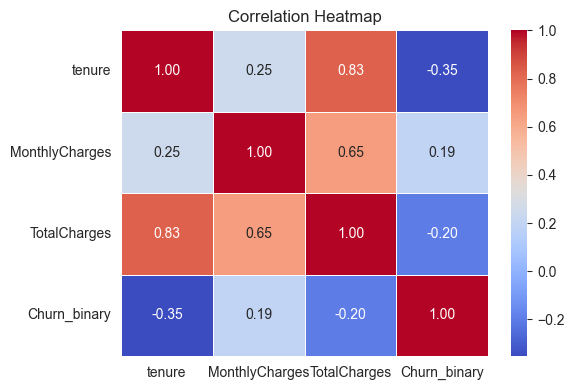

In [9]:
# Fix TotalCharges BEFORE heatmap (convert spaces to NaN, then to float)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
corr_df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150)
plt.show()

In [16]:
# Step 1: Drop customerID safely (errors='ignore' prevents crash if already dropped)
df.drop('customerID', axis=1, inplace=True, errors='ignore')

# Step 2: Fix TotalCharges properly
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 3: Check missing values
print("Missing values BEFORE cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Step 4: Fill missing TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("\nMissing values AFTER cleaning:")
print(df.isnull().sum().sum(), "← should be 0")

Missing values BEFORE cleaning:
Series([], dtype: int64)

Missing values AFTER cleaning:
0 ← should be 0


In [18]:
# Step 1: Encode target column (Yes/No → 1/0)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Step 2: Find all remaining categorical (text) columns
cat_columns = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_columns)

# Step 3: Label Encode all of them
le = LabelEncoder()
for col in cat_columns:
    df[col] = le.fit_transform(df[col])

# Step 4: Verify everything is now numeric
print("\nData types after encoding:")
print(df.dtypes)

print("\nChurn value counts (should be 0 and 1 only):")
print(df['Churn'].value_counts())

print("\nSample data:")
print(df.head())

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Data types after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Churn value counts (should be 0 and 1 only):
Churn
0    5174
1    1869
Name: count, dtype: int64

Sample data:
   gender  Seni

In [19]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling done ✅")

Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Train size: (5634, 19)
Test size:  (1409, 19)

Scaling done ✅


In [20]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
    }

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))


  Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


  Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


  XGBoost
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.60      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77

                     Accuracy  F1 Score  Precision  Recall
Logistic Regression     79.91     59.16      64.26   54.81
Random Forest           79.21     56.20      63.73   50.27
XGBoost                 77.86     55.30      59.57   51.60


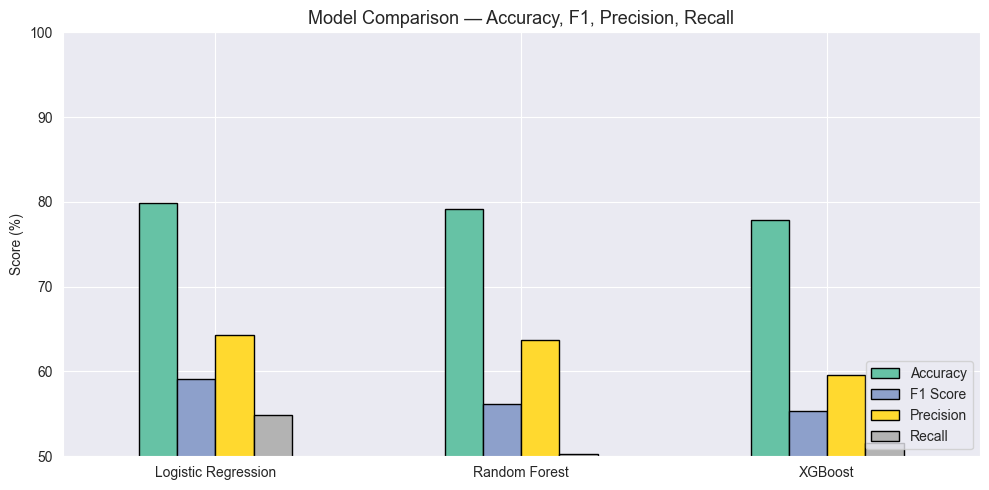

In [21]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — Accuracy, F1, Precision, Recall', fontsize=13)
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(50, 100)
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150)
plt.show()

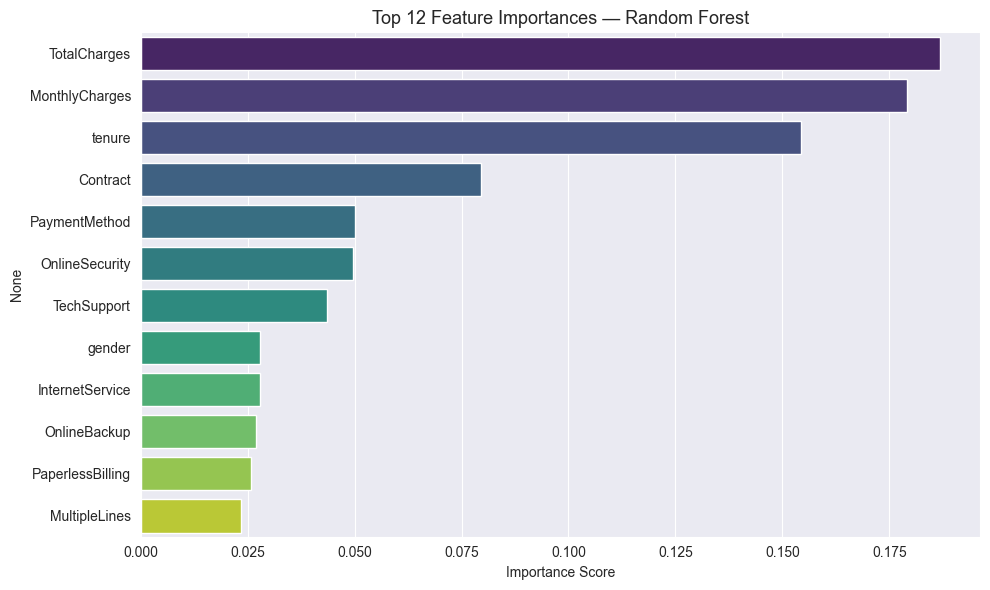


Top 5 churn drivers:
TotalCharges      0.186841
MonthlyCharges    0.179192
tenure            0.154338
Contract          0.079631
PaymentMethod     0.050095
dtype: float64


In [22]:
# Feature Importance Plot
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_,
                        index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:12],
            y=importances.index[:12],
            palette='viridis')
plt.title('Top 12 Feature Importances — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 churn drivers:")
print(importances.head())

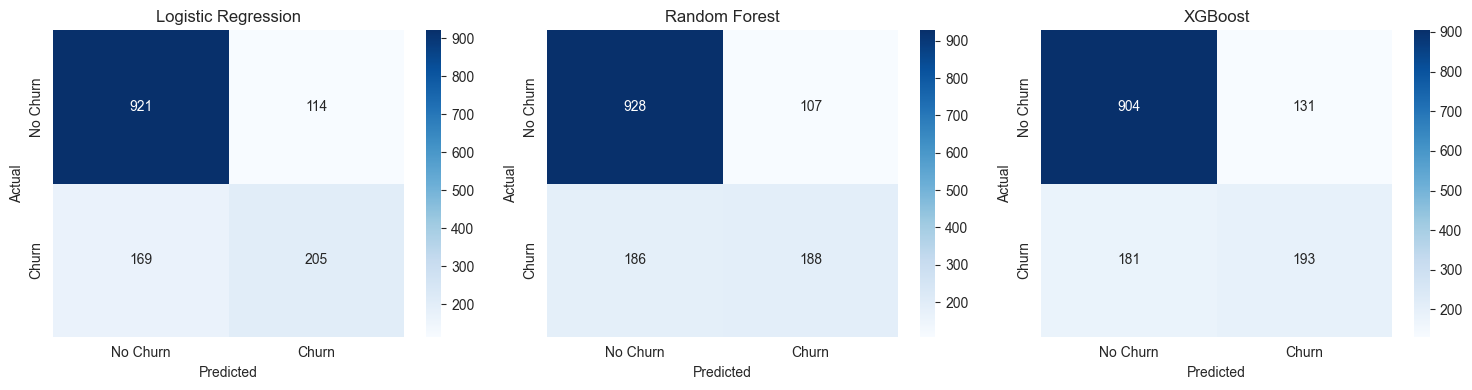

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_list = [
    ('Logistic Regression', models['Logistic Regression'], X_test_scaled),
    ('Random Forest',       models['Random Forest'],       X_test),
    ('XGBoost',             models['XGBoost'],             X_test),
]

for ax, (name, model, X_input) in zip(axes, model_list):
    cm = confusion_matrix(y_test, model.predict(X_input))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../images/confusion_matrices.png', dpi=150)
plt.show()

In [25]:
print("=" * 50)
print("       FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(results_df.to_string())
print("\n✅ Best F1 Score:  ", results_df['F1 Score'].idxmax(),
      "—", results_df['F1 Score'].max(), "%")
print("✅ Best Accuracy:  ", results_df['Accuracy'].idxmax(),
      "—", results_df['Accuracy'].max(), "%")
print("✅ Best Recall:    ", results_df['Recall'].idxmax(),
      "—", results_df['Recall'].max(), "%")
print("✅ Best Precision: ", results_df['Precision'].idxmax(),
      "—", results_df['Precision'].max(), "%")


       FINAL MODEL PERFORMANCE SUMMARY
                     Accuracy  F1 Score  Precision  Recall
Logistic Regression     79.91     59.16      64.26   54.81
Random Forest           79.21     56.20      63.73   50.27
XGBoost                 77.86     55.30      59.57   51.60

✅ Best F1 Score:   Logistic Regression — 59.16 %
✅ Best Accuracy:   Logistic Regression — 79.91 %
✅ Best Recall:     Logistic Regression — 54.81 %
✅ Best Precision:  Logistic Regression — 64.26 %
